# Hyperparameter Tuning - XGBoost

In this notebook, we improve the performance of the XGBoost model by tuning its hyperparameters using RandomizedSearchCV.

Objectives:

- Load the processed dataset
- Perform hyperparameter tuning
- Train the optimized model
- Save the best model
- Evaluate the tuned model

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

## Load Dataset

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape)

print(X_test.shape)

(453204, 33)
(56746, 33)


## Create Base XGBoost Model

In [3]:
xgb = XGBClassifier(

    random_state=42,

    eval_metric="logloss"

)

## Hyperparameter Search Space

In [4]:
param_dist = {

    "n_estimators":[100,200,300,500],

    "max_depth":[3,4,5,6,8,10],

    "learning_rate":[0.01,0.05,0.1,0.2,0.3],

    "subsample":[0.6,0.8,1.0],

    "colsample_bytree":[0.6,0.8,1.0],

    "gamma":[0,0.1,0.2,0.5],

    "min_child_weight":[1,3,5]

}

## RandomizedSearchCV

In [5]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_dist,

    n_iter=20,

    scoring="f1",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

## Train Model

In [6]:
random_search.fit(

    X_train,

    y_train

)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=10, min_child_weight=5, n_estimators=100, subsample=1.0; total time=   4.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=10, min_child_weight=5, n_estimators=100, subsample=1.0; total time=   4.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=10, min_child_weight=5, n_estimators=100, subsample=1.0; total time=   4.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.8; total time=   7.9s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.6; total time=   4.7s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth=10, min_child_weight=5, n_estimators=300, subsample=1.0; total time=  10.5s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

## Best Hyperparameters

In [7]:
print("Best Parameters")

print("-"*50)

print(random_search.best_params_)

Best Parameters
--------------------------------------------------
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}


## Best Cross Validation Score  

In [8]:
print("Best F1 Score")

print("-"*50)

print(random_search.best_score_)

Best F1 Score
--------------------------------------------------
0.9998190996444597


## Best Model

In [9]:
best_model = random_search.best_estimator_

best_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Save Tuned Model

In [10]:
joblib.dump(

    best_model,

    "../models/xgboost_tuned.pkl"

)

print("Tuned XGBoost model saved successfully.")

Tuned XGBoost model saved successfully.


## Predictions

In [11]:
y_pred = best_model.predict(

    X_test

)

y_prob = best_model.predict_proba(

    X_test

)[:,1]

## Accuracy

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9994


## Precision

In [13]:
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision : {precision:.4f}")

Precision : 0.8706


## Recall

In [14]:
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall : {recall:.4f}")

Recall : 0.7789


## F1 Score

In [15]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.8222


## Classification Report

In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.78      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.89      0.91     56746
weighted avg       1.00      1.00      1.00     56746



## Confusion Matrix

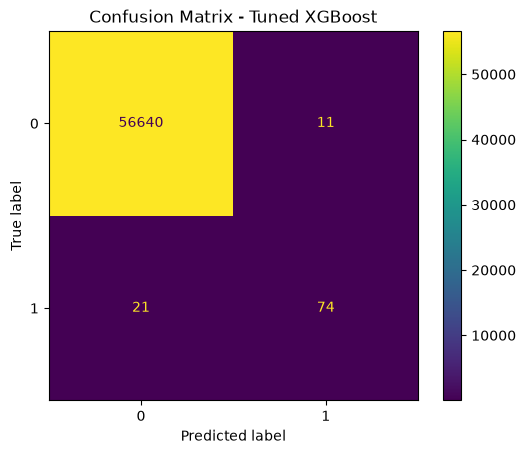

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Tuned XGBoost")

plt.savefig(
    "../artifacts/plots/xgboost_tuned_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC-AUC

In [18]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.9690


## ROC Curve

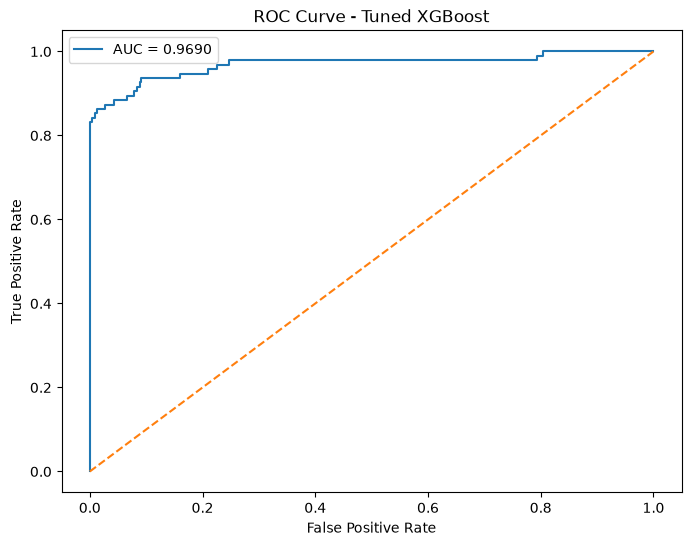

In [19]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned XGBoost")

plt.legend()

plt.savefig(
    "../artifacts/plots/xgboost_tuned_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Importance

In [20]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(20)

,Feature,Importance
14,V14,0.431568
10,V10,0.251276
4,V4,0.033848
8,V8,0.022786
3,V3,0.018203
17,V17,0.017471
2,V2,0.015966
32,Amount_Level,0.014802
25,V25,0.012408
19,V19,0.011588


## Plot Feature Importance

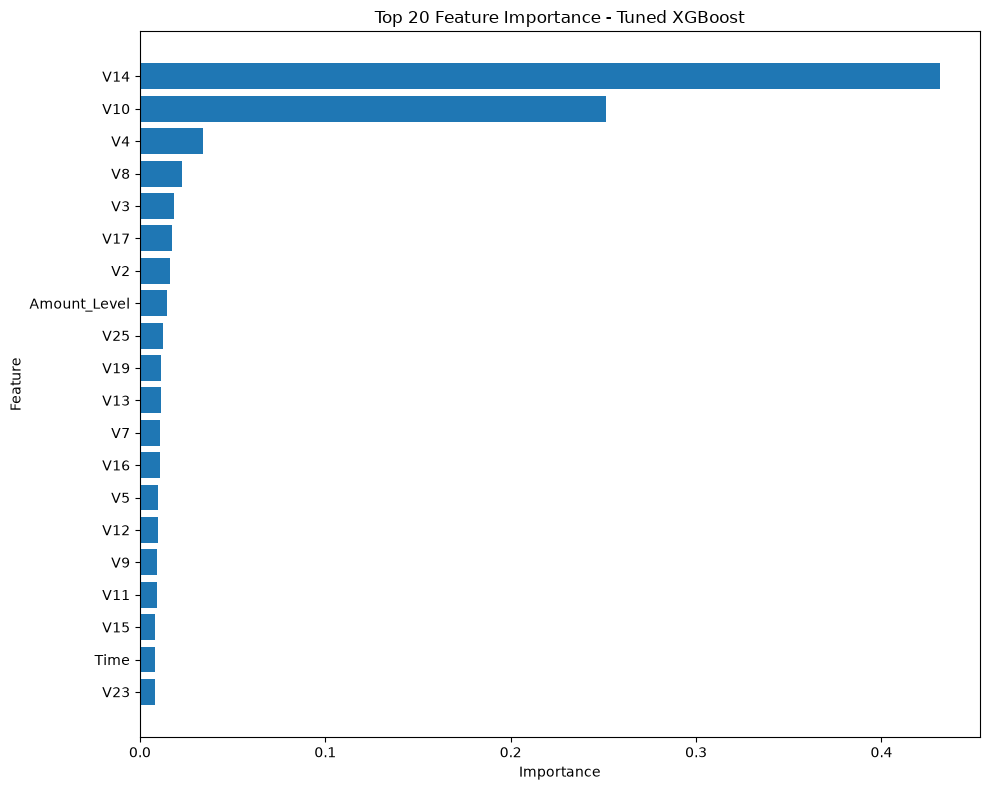

In [21]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 20 Feature Importance - Tuned XGBoost")

plt.tight_layout()

plt.savefig(
    "../artifacts/plots/xgboost_tuned_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Create Results DataFrame

In [22]:
tuned_results = pd.DataFrame({

    "Model":["Tuned XGBoost"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1 Score":[f1],

    "ROC-AUC":[roc_auc]

})

tuned_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned XGBoost,0.999436,0.870588,0.778947,0.822222,0.96896


## Save Results

In [23]:
tuned_results.to_csv(

    "../results/hyperparameter_tuning.csv",

    index=False

)

print("Hyperparameter tuning results saved successfully.")

Hyperparameter tuning results saved successfully.


## Compare Baseline vs Tuned XGBoost

In [24]:
baseline = pd.read_csv(
    "../results/xgboost_metrics.csv"
)

comparison = pd.concat(

    [
        baseline,
        tuned_results
    ],

    ignore_index=True

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.999207,0.755102,0.778947,0.766839,0.959746
1,Tuned XGBoost,0.999436,0.870588,0.778947,0.822222,0.968960


## Save Comparison

In [25]:
comparison.to_csv(

    "../results/xgboost_comparison.csv",

    index=False

)

print("Comparison saved successfully.")

Comparison saved successfully.


## Final Recommendation

In [26]:
best = comparison.sort_values(

    by="F1 Score",

    ascending=False

).iloc[0]

print("="*60)

print("Best XGBoost Model")

print("="*60)

print(best)

Best XGBoost Model
Model        Tuned XGBoost
Accuracy          0.999436
Precision         0.870588
Recall            0.778947
F1 Score          0.822222
ROC-AUC            0.96896
Name: 1, dtype: object


# Conclusion

Hyperparameter tuning was performed using RandomizedSearchCV to optimize the XGBoost classifier.

The tuned model was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The tuned model was then compared with the baseline XGBoost model to determine whether hyperparameter optimization improved overall performance.

The best-performing model will be considered during the final model comparison alongside Logistic Regression, Decision Tree, and Random Forest variants.